# Exploratory Data Analysis - IPL
### Exploratory Data Analysis' on dataset 'Indian Premier League'. To find out the most successful teams, players and factors contributing win or loss of a team. Suggest teams or players a company should endorse for its products?

## first we will import the necessary libraries 📚 of python

###Pandas =  used for reading and analyzing datasets.

###NumPy = used for numerical calculations.

###Matplotlib = used for creating charts and graphs.

###Seaborn = used for advanced statistical visualizations.



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##Reading the data

In [11]:
df = pd.read_excel("matches.xlsx")
df.head()

# pd.read_csv() reads the CSV file and converts it into a DataFrame.
# df.head() displays the first 5 rows to verify the dataset.

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


##Visualizing the data

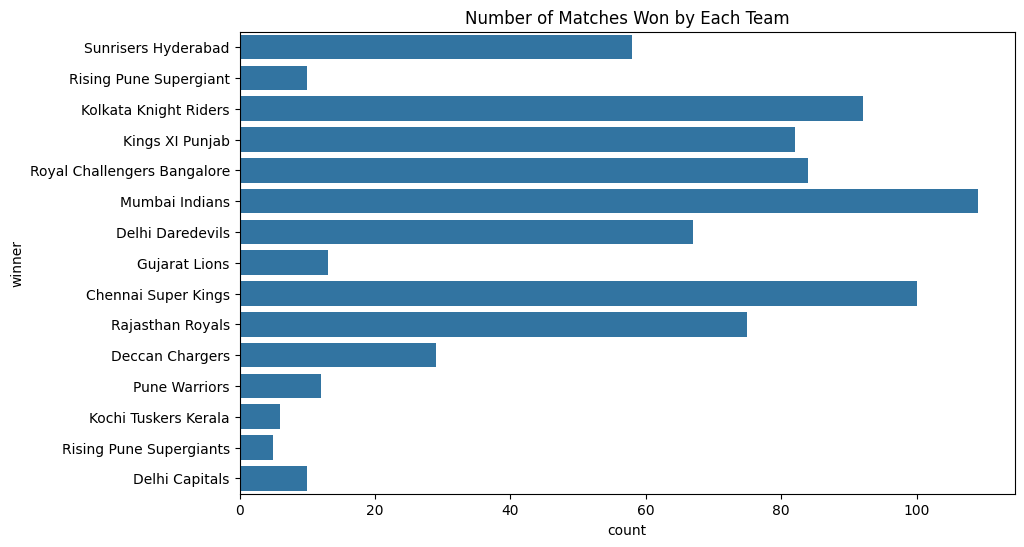

In [12]:
#The graph shows how many matches each team has won.
plt.figure(figsize=(10,6))
sns.countplot(y=df["winner"])
plt.title("Number of Matches Won by Each Team")
plt.show()


# plt.figure creates a new figure for plotting.

# figsize=(10,6) sets the width and height of the chart.

# countplot() counts the frequency of values in a column.

# y=df['winner'] means team names will appear on the vertical axis.

# plt.title("Number of Matches Won by Each Team") Adds a title to the chart so viewers understand what the graph represents.

# plt.show() Displays the final graph.


##Cleaning the data

In [13]:
df.info()
df.isnull().sum()

# df.info() this function displays:
# total number of rows
# column names
# data types
# number of non-null values
# to understand the structure of the dataset
# so the below table will tell us in total how many null value is there in each table



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               756 non-null    int64         
 1   season           756 non-null    int64         
 2   city             749 non-null    object        
 3   date             756 non-null    datetime64[ns]
 4   team1            756 non-null    object        
 5   team2            756 non-null    object        
 6   toss_winner      756 non-null    object        
 7   toss_decision    756 non-null    object        
 8   result           756 non-null    object        
 9   dl_applied       756 non-null    int64         
 10  winner           752 non-null    object        
 11  win_by_runs      756 non-null    int64         
 12  win_by_wickets   756 non-null    int64         
 13  player_of_match  752 non-null    object        
 14  venue            756 non-null    object   

,0
id,0
season,0
city,7
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


##Removing duplicate values and Statistical Information of the Data

In [14]:
df = df.drop_duplicates()
df.describe()
# removes rows that are exact copies of other rows
# duplicate rows may happen during data collection.

# df.describe() shows:

# count, total number of values

# mean, average value

# std, standard deviation

# min, smallest value

# max, largest value


,id,season,date,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756,756.000000,756.000000,756.000000
mean,1792.178571,2013.444444,2013-10-07 06:22:51.428571392,0.025132,13.283069,3.350529
min,1.000000,2008.000000,2008-04-18 00:00:00,0.000000,0.000000,0.000000
25%,189.750000,2011.000000,2011-04-16 00:00:00,0.000000,0.000000,0.000000
50%,378.500000,2013.000000,2013-05-09 12:00:00,0.000000,0.000000,4.000000
75%,567.250000,2016.000000,2016-05-18 06:00:00,0.000000,19.000000,6.000000
max,11415.000000,2019.000000,2019-05-12 00:00:00,1.000000,146.000000,10.000000
std,3464.478148,3.366895,NaN,0.156630,23.471144,3.387963


##Total number of innings of the matches played

In [15]:
total_matches = df.shape[0]              # returns the dimensions of the dataset
total_innings = total_matches* 2         # each cricket match has 2 innihngs so we multipoly by 2 to find total innings
print(total_innings)


1512


##How many IPL seasons are we using to analyse ?

In [16]:
df["season"] =pd.DatetimeIndex(df["date"]).year
df["season"].nunique()


# pd.DatetimeIndex(df['date']).year Converts the date column into a datetime format.Extracts the year from the date.

# for example 2008-03-22 it will extract 2008

# nunique() count number of unique values

12

##Total number of matches played according to the dataset

In [17]:
df['id'].nunique()  # Each match has a unique match ID

756

##Each match has a unique match ID

In [18]:
df.loc[df["win_by_runs"].idxmax()]

# idxmax() Finds the row index of the maximum value in win_by_runs

# df.loc[] Retrieves the entire row corresponding to that index. This shows the team that achieved the largest run victory.

,43
id,44
season,2017
city,Delhi
date,2017-05-06 00:00:00
team1,Mumbai Indians
team2,Delhi Daredevils
toss_winner,Delhi Daredevils
toss_decision,field
result,normal
dl_applied,0


##Which IPL team won by minimum runs ?

In [19]:
df.loc[df['win_by_runs'].idxmin()]

# idxmin() Finds the smallest value in win_by_runs.

,1
id,2
season,2017
city,Pune
date,2017-04-06 00:00:00
team1,Mumbai Indians
team2,Rising Pune Supergiant
toss_winner,Rising Pune Supergiant
toss_decision,field
result,normal
dl_applied,0


##Which IPL team won by consuming maximum wickets?

In [20]:
df.loc[df['win_by_wickets'].idxmax()]

,2
id,3
season,2017
city,Rajkot
date,2017-04-07 00:00:00
team1,Gujarat Lions
team2,Kolkata Knight Riders
toss_winner,Kolkata Knight Riders
toss_decision,field
result,normal
dl_applied,0


##Which IPL team won by consuming minimum wickets?

In [21]:
df.loc[df['win_by_wickets'].idxmin()]

# idxmin() finds the smallest value in the win_by_wickets column.

,0
id,1
season,2017
city,Hyderabad
date,2017-04-05 00:00:00
team1,Sunrisers Hyderabad
team2,Royal Challengers Bangalore
toss_winner,Royal Challengers Bangalore
toss_decision,field
result,normal
dl_applied,0


#Visualization

##Which season consisted of the highest number of matches ever played ?

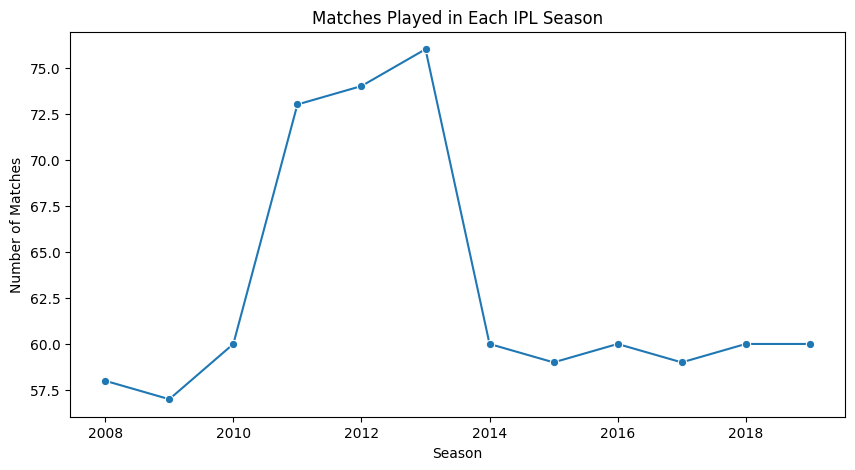

In [34]:
season_matches = df['season'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=season_matches.index, y=season_matches.values, marker="o")
plt.title("Matches Played in Each IPL Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.show()

# value_counts() counts matches per season

# sort_index() arranges seasons chronologically

# lineplot() shows the trend across seasons


# The season with the highest point on the line graph represents the season with the most matches played

##Which is the most successful IPL team with all the data at hand?

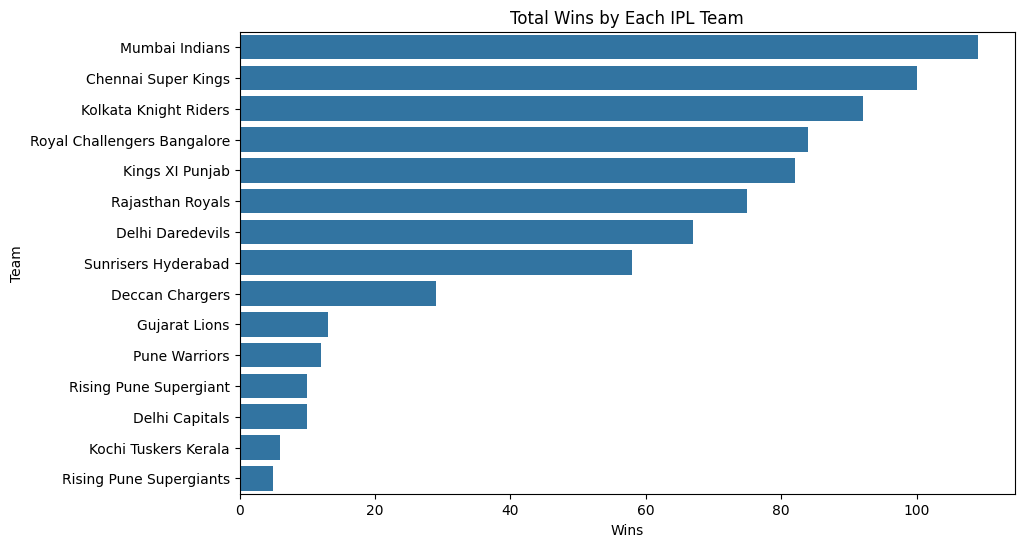

In [37]:
team_wins = df['winner'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=team_wins.values, y=team_wins.index)
plt.title("Total Wins by Each IPL Team")
plt.xlabel("Wins")
plt.ylabel("Team")
plt.show()

# Count how many times each team appears in the winner column.

# Horizontal bars improve readability when many teams exist.

# The team with the longest bar has the highest number of wins, making it the most successful team.

##Top players of winning matches

/tmp/ipykernel_544/1942554663.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_players.values, y=top_players.index, palette="viridis")


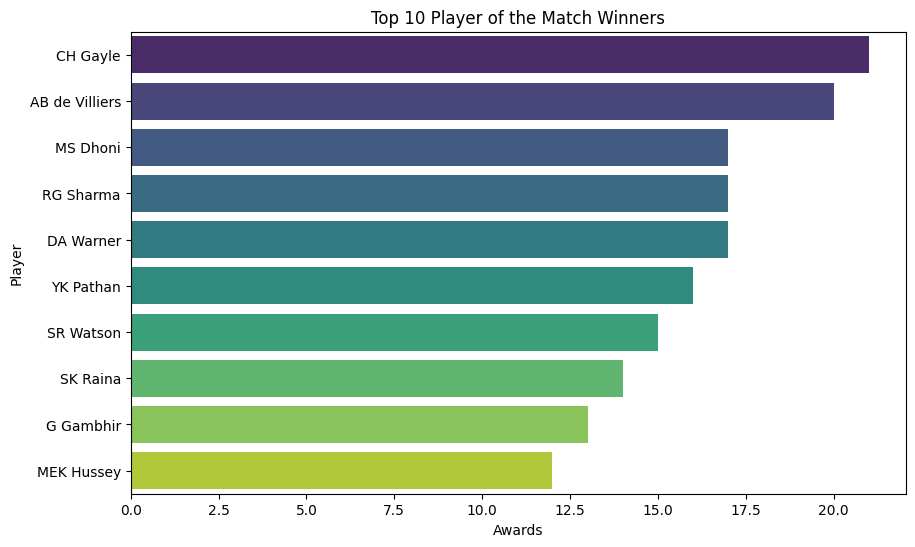

In [40]:
top_players = df['player_of_match'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_players.values, y=top_players.index, palette="viridis")
plt.title("Top 10 Player of the Match Winners")
plt.xlabel("Awards")
plt.ylabel("Player")
plt.show()

# value_counts() counts Player-of-the-Match awards

# head(10) selects the top 10

# Players with more awards appear higher in the chart, indicating the most impactful performers.


##Matches according to venue

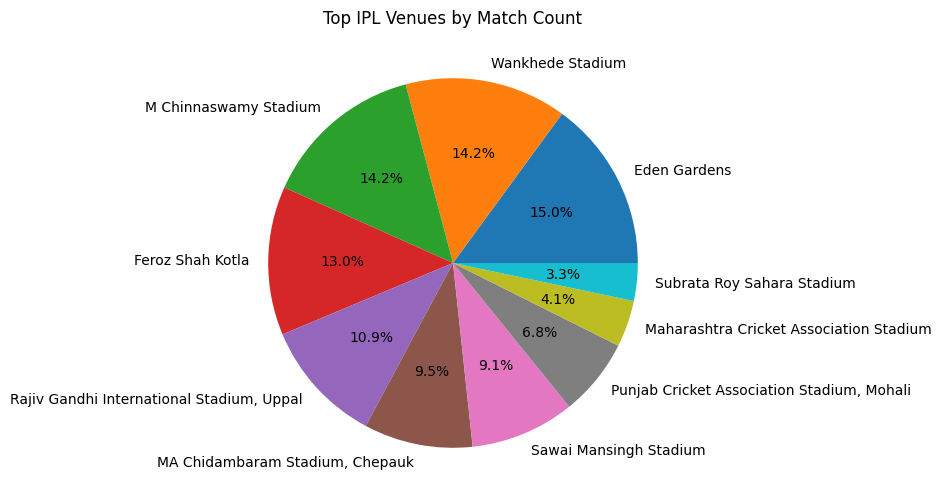

In [42]:
venue_matches = df['venue'].value_counts().head(10)

plt.figure(figsize=(10,6))
venue_matches.plot(kind="pie", autopct='%1.1f%%')
plt.title("Top IPL Venues by Match Count")
plt.ylabel("")
plt.show()

# Count matches per venue

# Pie chart shows proportion of matches hosted.



# The largest slice represents the venue hosting the most matches.

##The number of matches played by each team

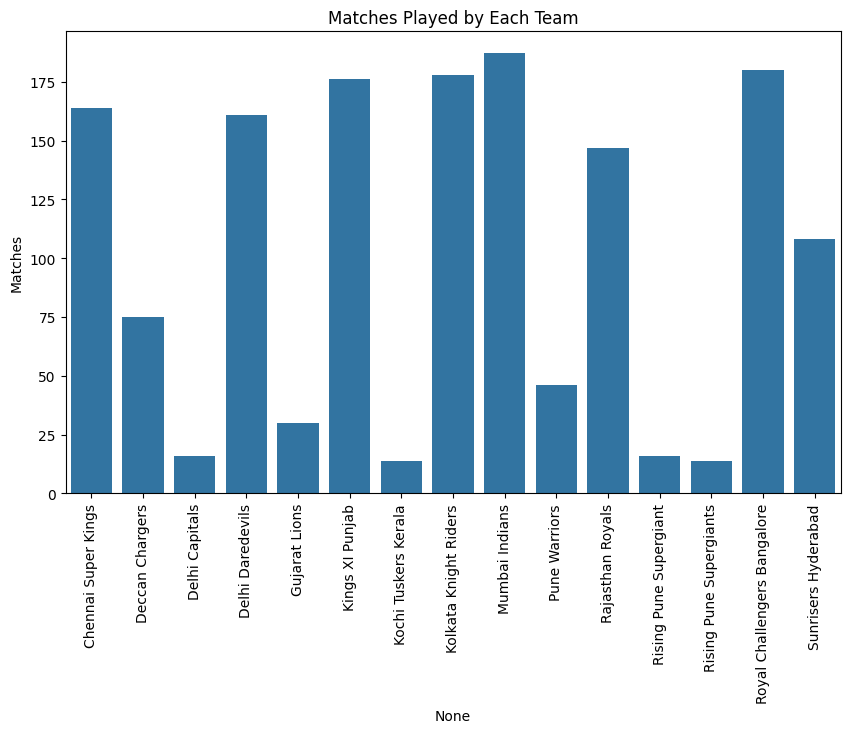

In [44]:
team1 = df['team1'].value_counts()
team2 = df['team2'].value_counts()

total_matches = team1.add(team2, fill_value=0)

plt.figure(figsize=(10,6))
sns.barplot(x=total_matches.index, y=total_matches.values)
plt.xticks(rotation=90)
plt.title("Matches Played by Each Team")
plt.ylabel("Matches")
plt.show()

# teams appear in two columns (team1 and team2), so we add their counts.


# The bars represent total matches played by each team.

##The winners in each Season

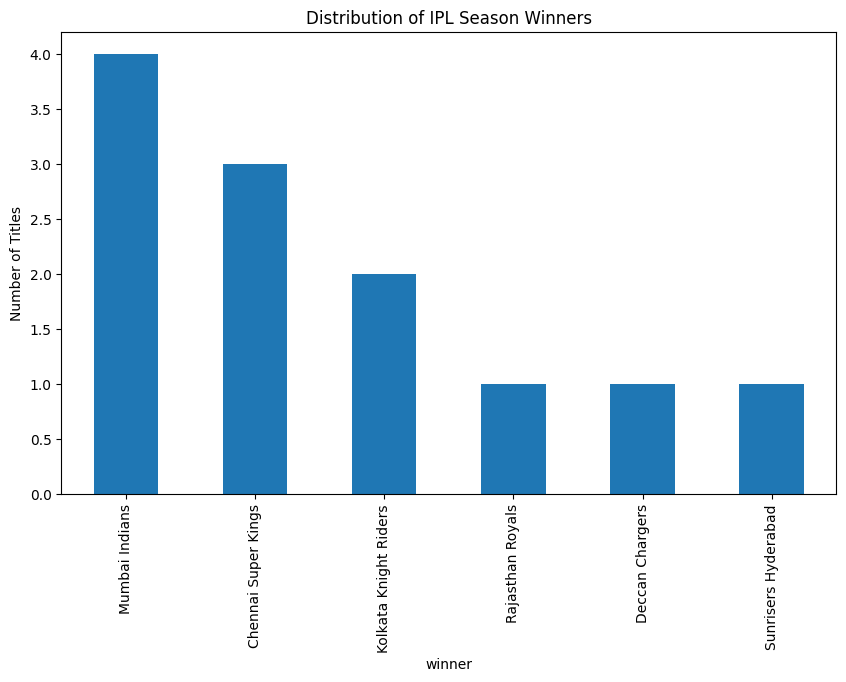

In [45]:
season_winners = df.groupby('season')['winner'].last()

plt.figure(figsize=(10,6))
season_winners.value_counts().plot(kind='bar')
plt.title("Distribution of IPL Season Winners")
plt.ylabel("Number of Titles")
plt.show()

# Group matches by season.

# The last match in a season = final.

# The winner of the final match is the champion.

##IPL Finals venues and winners along with the number of wins.

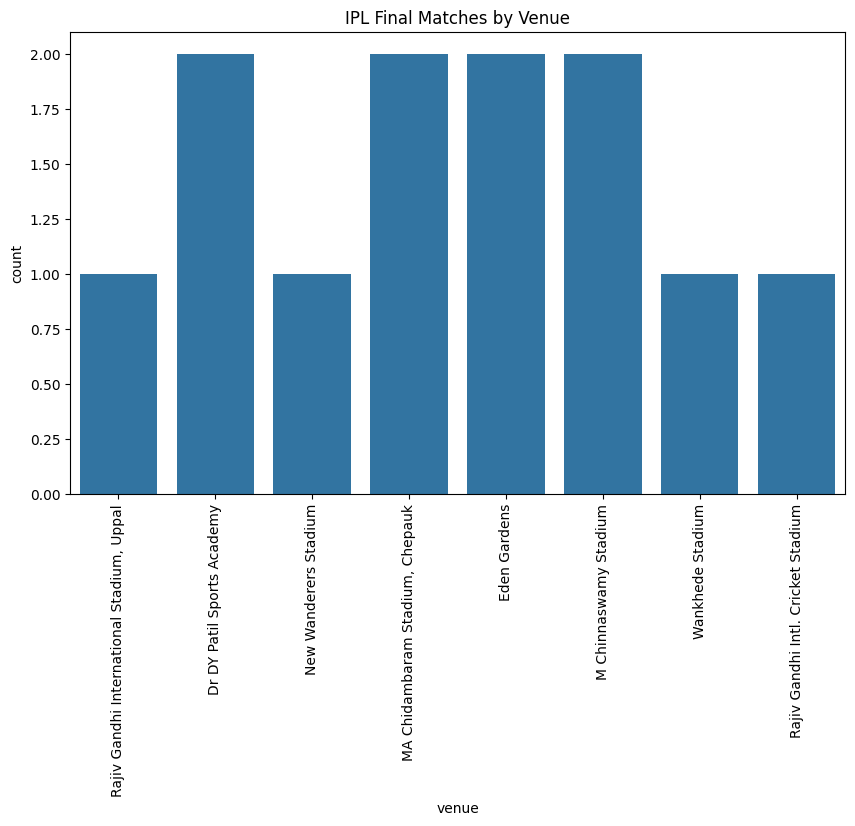

In [46]:
finals = df.drop_duplicates(subset='season', keep='last')

plt.figure(figsize=(10,6))
sns.countplot(data=finals, x='venue')
plt.xticks(rotation=90)
plt.title("IPL Final Matches by Venue")
plt.show()

# drop_duplicates() keeps only final matches.

# Bars show how many finals each stadium hosted.


##The number of seasons won by each team

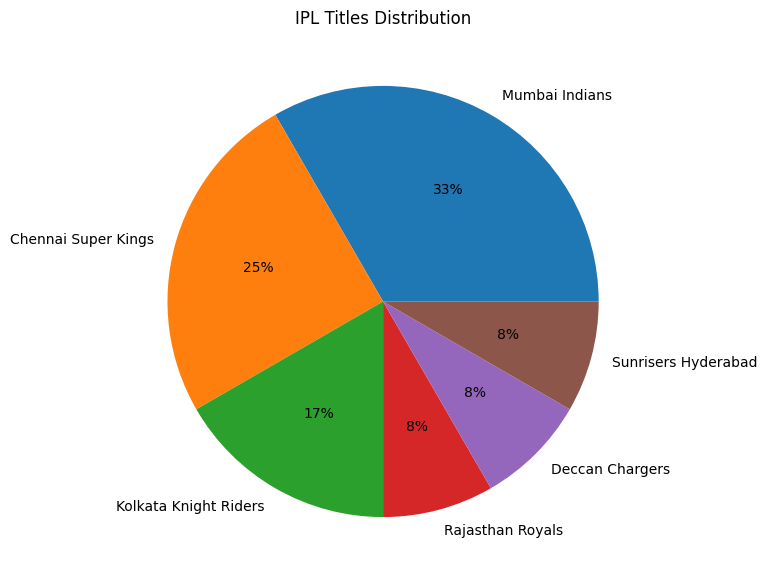

In [52]:
titles = finals['winner'].value_counts()

plt.figure(figsize=(7,7))
titles.plot(kind='pie', autopct='%1.0f%%')
plt.title("IPL Titles Distribution")
plt.ylabel("")
plt.show()

# Pie chart shows share of championships per team.

##Pie chart shows share of championships per team.

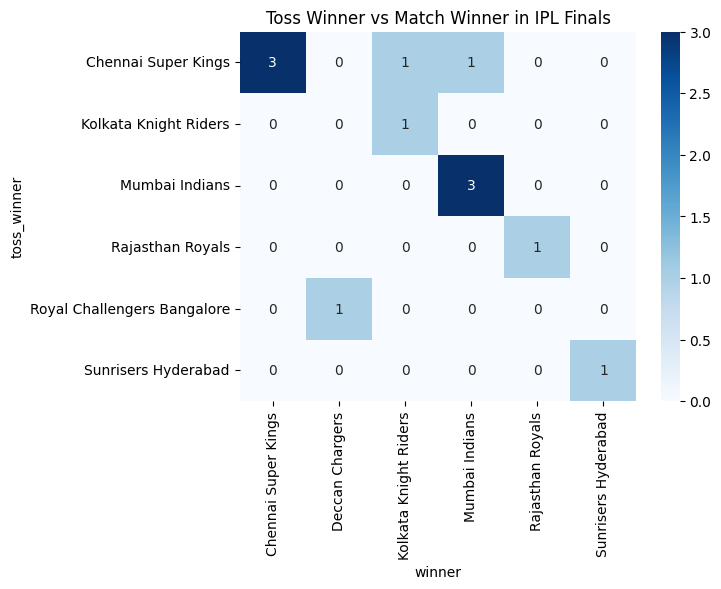

In [58]:
sns.heatmap(pd.crosstab(finals['toss_winner'], finals['winner']), annot=True, cmap="Blues")
plt.title("Toss Winner vs Match Winner in IPL Finals")
plt.show()

# crosstab() creates a comparison table.

# Heatmap highlights relationships

# This shows whether winning the toss correlates with winning finals

##The man of the match for each winning team

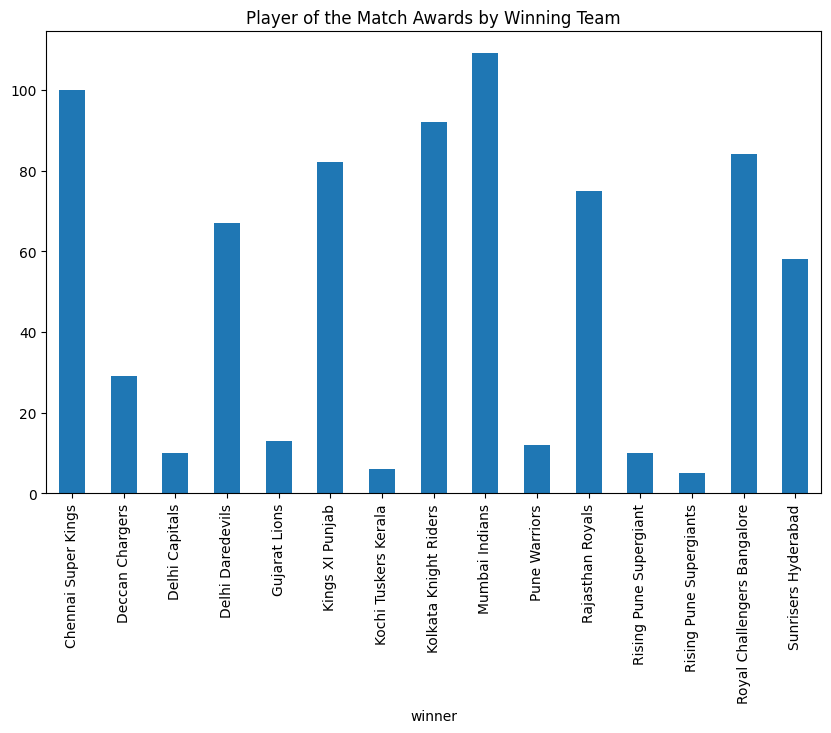

In [59]:
mom_team = df.groupby('winner')['player_of_match'].count()

plt.figure(figsize=(10,6))
mom_team.plot(kind='bar')
plt.title("Player of the Match Awards by Winning Team")
plt.show()

#Shows how many MVP performances occurred in matches each team won.

##Decision in every toss either fielding or batting

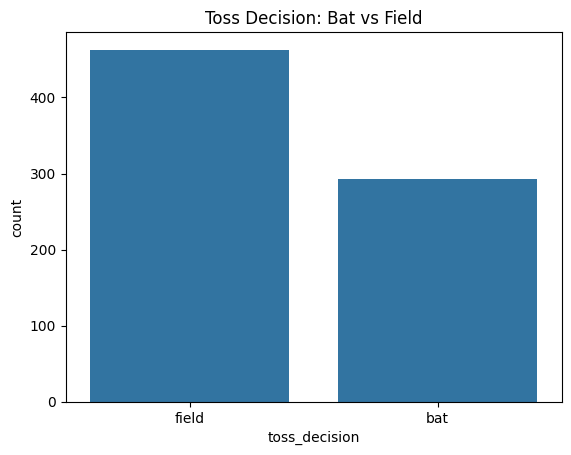

In [60]:
sns.countplot(data=df, x='toss_decision')
plt.title("Toss Decision: Bat vs Field")
plt.show()

# This compares batting first vs fielding first decisions

##What is the probability of winning a match if the toss was won?

In [61]:
toss_win = df[df['toss_winner'] == df['winner']]

prob = len(toss_win) / len(df)

print("Probability:", prob)

# Filter matches where toss winner = match winner

Probability: 0.5198412698412699
